<a href="https://colab.research.google.com/github/Aabhiinavvv/face_detection_classification/blob/main/face_mask_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kaggle


In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")

print("Path to dataset files:", path)

100%|██████████| 163M/163M [00:01<00:00, 158MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/omkargurav/face-mask-dataset/versions/1


In [5]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:00<00:00, 309MB/s]



In [6]:
from zipfile import ZipFile
dataset = "/content/face-mask-dataset.zip"

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [7]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data


In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [9]:
with_mask_images = os.listdir("/content/data/with_mask")
print(with_mask_images[0:5])
print(with_mask_images[-5:])

['with_mask_2442.jpg', 'with_mask_205.jpg', 'with_mask_2201.jpg', 'with_mask_636.jpg', 'with_mask_1904.jpg']
['with_mask_1748.jpg', 'with_mask_2500.jpg', 'with_mask_3195.jpg', 'with_mask_1317.jpg', 'with_mask_1242.jpg']


In [10]:
without_mask_images = os.listdir("/content/data/without_mask")
print(with_mask_images[0:5])
print(with_mask_images[-5:])

['with_mask_2442.jpg', 'with_mask_205.jpg', 'with_mask_2201.jpg', 'with_mask_636.jpg', 'with_mask_1904.jpg']
['with_mask_1748.jpg', 'with_mask_2500.jpg', 'with_mask_3195.jpg', 'with_mask_1317.jpg', 'with_mask_1242.jpg']


In [11]:
print(len(with_mask_images))
print(len(without_mask_images))

3725
3828


creating label for the classes

1.   1 --> with mask
2.   0 -->without mask





In [12]:
with_mask_labels = [1]*len(with_mask_images)
without_mask_labels = [0]*len(without_mask_images)

In [13]:
print(with_mask_images[0:5])
print(without_mask_images[0:5])

['with_mask_2442.jpg', 'with_mask_205.jpg', 'with_mask_2201.jpg', 'with_mask_636.jpg', 'with_mask_1904.jpg']
['without_mask_2852.jpg', 'without_mask_1877.jpg', 'without_mask_2708.jpg', 'without_mask_3085.jpg', 'without_mask_1468.jpg']


In [14]:
print(len(with_mask_images))
print(len(without_mask_images))

3725
3828


In [15]:
labels = with_mask_labels + without_mask_labels
print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


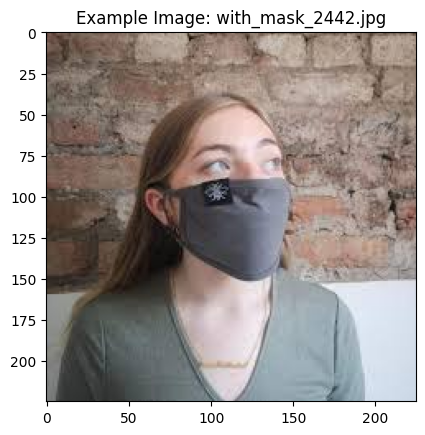

In [16]:
 img = mpimg.imread("/content/data/with_mask/" + with_mask_images[0])
imgplot= plt.imshow(img)
plt.title(f"Example Image: {with_mask_images[0]}")
plt.show()

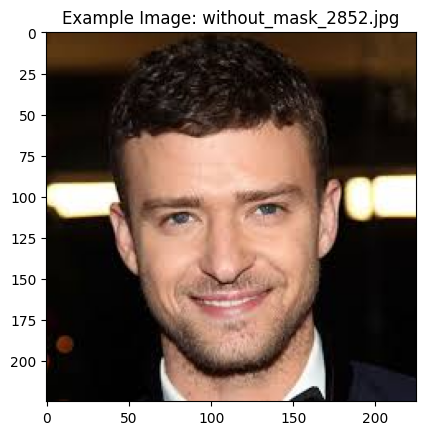

In [17]:
img = mpimg.imread("/content/data/without_mask/" + without_mask_images[0])
imgplot= plt.imshow(img)
plt.title(f"Example Image: {without_mask_images[0]}")
plt.show()

In [18]:
import numpy as np
import os
from PIL import Image

image_data = []

with_mask_images = os.listdir("/content/data/with_mask")
without_mask_images = os.listdir("/content/data/without_mask")

mask_dir = "/content/data/with_mask/"
no_mask_dir = "/content/data/without_mask/"

for img_file in with_mask_images:
    try:
        image_path = os.path.join(mask_dir, img_file)
        image = Image.open(image_path)
        image = image.resize((128, 128))
        image = image.convert("RGB")
        image_data.append(np.array(image))
    except Exception as e:
        print(f"Error processing {img_file} from with_mask: {e}")


for img_file in without_mask_images:
    try:
        image_path = os.path.join(no_mask_dir, img_file)
        image = Image.open(image_path)
        image = image.resize((128, 128))
        image = image.convert("RGB")
        image_data.append(np.array(image))
    except Exception as e:
        print(f"Error processing {img_file} from without_mask: {e}")

print(f"Total images preprocessed: {len(image_data)}")
print(f"Shape of the first image array: {image_data[0].shape}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Total images preprocessed: 7553
Shape of the first image array: (128, 128, 3)


Now that the images are preprocessed and converted into NumPy arrays, we can convert the `image_data` list and `labels` list into NumPy arrays for further processing, such as splitting into training and testing sets.

In [20]:
type(image_data)

list

In [21]:
len(image_data)

7553

array([[[110,  81,  73],
        [104,  77,  68],
        [ 94,  66,  58],
        ...,
        [133, 115, 101],
        [118, 100,  86],
        [100,  82,  68]],

       [[104,  76,  68],
        [116,  89,  80],
        [ 99,  71,  63],
        ...,
        [163, 145, 131],
        [147, 129, 115],
        [128, 110,  96]],

       [[112,  85,  76],
        [110,  82,  73],
        [107,  81,  72],
        ...,
        [178, 160, 146],
        [175, 157, 143],
        [168, 150, 136]],

       ...,

       [[124, 126, 125],
        [122, 124, 123],
        [122, 124, 123],
        ...,
        [205, 217, 231],
        [205, 217, 231],
        [204, 216, 229]],

       [[124, 126, 125],
        [121, 123, 122],
        [121, 123, 122],
        ...,
        [205, 217, 231],
        [204, 216, 230],
        [204, 216, 229]],

       [[123, 125, 124],
        [119, 121, 120],
        [120, 122, 121],
        ...,
        [204, 216, 230],
        [204, 216, 230],
        [204, 216, 229]]], dtype=uint8)
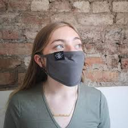

In [22]:

image_data[0]

In [23]:
type(image_data[0])

numpy.ndarray

In [24]:
image_data[0].shape

(128, 128, 3)

In [25]:
x = np.array(image_data)
y = np.array(labels)

In [26]:
print(x.shape)
print(y.shape)

(7553, 128, 128, 3)
(7553,)


In [27]:
print(y)

[1 1 1 ... 0 0 0]


In [28]:
print(x)

[[[[110  81  73]
   [104  77  68]
   [ 94  66  58]
   ...
   [133 115 101]
   [118 100  86]
   [100  82  68]]

  [[104  76  68]
   [116  89  80]
   [ 99  71  63]
   ...
   [163 145 131]
   [147 129 115]
   [128 110  96]]

  [[112  85  76]
   [110  82  73]
   [107  81  72]
   ...
   [178 160 146]
   [175 157 143]
   [168 150 136]]

  ...

  [[124 126 125]
   [122 124 123]
   [122 124 123]
   ...
   [205 217 231]
   [205 217 231]
   [204 216 229]]

  [[124 126 125]
   [121 123 122]
   [121 123 122]
   ...
   [205 217 231]
   [204 216 230]
   [204 216 229]]

  [[123 125 124]
   [119 121 120]
   [120 122 121]
   ...
   [204 216 230]
   [204 216 230]
   [204 216 229]]]


 [[[209 219 221]
   [211 213 211]
   [206 196 189]
   ...
   [ 87  96 111]
   [ 79  88 103]
   [ 73  82  98]]

  [[215 220 220]
   [208 206 202]
   [200 189 182]
   ...
   [ 81  92 106]
   [ 83  94 108]
   [ 81  92 106]]

  [[219 220 215]
   [202 198 192]
   [194 182 175]
   ...
   [ 70  82  96]
   [ 76  88 102]
   [ 81  93

In [29]:
x_train,y_train ,y_test,x_test = train_test_split( x,y,random_state=2,test_size=0.2)

In [30]:
print(x_test.shape,x_train.shape)

(1511,) (6042, 128, 128, 3)


In [31]:
x_train_scaled = x_train/255
x_test_scaled = x_test/255

In [32]:
x_train_scaled

array([[[[0.30196078, 0.24313725, 0.25490196],
         [0.29803922, 0.23921569, 0.25098039],
         [0.31372549, 0.25490196, 0.27058824],
         ...,
         [0.35686275, 0.28627451, 0.30588235],
         [0.36470588, 0.28627451, 0.30980392],
         [0.34509804, 0.27058824, 0.29411765]],

        [[0.28235294, 0.22352941, 0.23529412],
         [0.29803922, 0.23921569, 0.24705882],
         [0.29411765, 0.23921569, 0.25490196],
         ...,
         [0.34117647, 0.2745098 , 0.29803922],
         [0.34117647, 0.26666667, 0.29019608],
         [0.3254902 , 0.25490196, 0.27843137]],

        [[0.28627451, 0.22745098, 0.23921569],
         [0.29019608, 0.23529412, 0.24705882],
         [0.27058824, 0.22352941, 0.23921569],
         ...,
         [0.33333333, 0.26666667, 0.29803922],
         [0.3254902 , 0.25882353, 0.28627451],
         [0.31764706, 0.25098039, 0.2745098 ]],

        ...,

        [[0.32156863, 0.28235294, 0.2627451 ],
         [0.34509804, 0.30588235, 0.27843137]

In [34]:
import tensorflow as tf
from tensorflow import keras


In [ ]:
num_of_classes = 2
model = keras.Sequential()

model.add(keras.layers.Convo2D(32,kernal_size=(3,3),activation='relu',input_shape=(128,128,3))
